# Model building and running with SPyice for heat-salt transport system

## Example 1: Demo to activate salt process model with heat model

Demonstrates a simple example for a freezing sea ice model **heat-salt transport setup** with default settings of initial conditions of 265K at the top boundary and Salinity of 34ppt choosing constant fixed Dirichlet boundary conditions. For the one phase distinct interface system where sea water is at melt temperature of 271.25K.


#### Import Packages

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime

%matplotlib inline
from omegaconf import OmegaConf

from spyice.utils import create_output_directory
from spyice.postprocess import Analysis, VisualiseModel
from spyice.utils import ConfigSort
from spyice.models import SeaIceModel
from spyice.preprocess import PreProcess

#### Define Inputs and Project Output paths

In [2]:
# creates a OmegaConf object from a dictionary for fast testing only for parameters: constants, dt, S_IC, iter_max, dz
# make sure to change userinput_data data class values if any parameters in constants_dict is changed!
constants_dict = {
    "constants": {"constants": "real"},
    "dt": {"dt": 47},
    "S_IC": {"S_IC": "S34"},
    "iter_max": {"iter_max": 1500},
    "dz": {"dz": 0.01},
}
config_raw = OmegaConf.create(constants_dict)
config = ConfigSort.getconfig_dataclass(config_raw, config_type="jupyter")

# choose your output directory
base_dir = Path.cwd()
output_base_dir = Path(base_dir, "output")
# Current date-time string
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_base_dir = Path(output_base_dir, timestamp)
wo_hydra_dir = Path(output_base_dir, "without_hydra")
out_dir_final = create_output_directory(wo_hydra_dir, config.initial_salinity.S_IC, "2", "0.01", "47", "1500","example")

#### Preprocessing

In [3]:
# preprocess the data
preprocess_data, userinput_data = PreProcess.get_variables(config_raw, out_dir_final)

Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.


#### Model settings

for more info on all the model parameters have a look at the documentation: [userinput](https://starry-phoenix.github.io/spyice-thesis/build/html/api/spyice.parameters.user_input.html)

In [4]:
# choose the diffusion only equation for heat diffusion without the influence of salinity and physical properties
userinput_data.is_diffusiononly_equation = True
userinput_data.is_salinity_equation = True

In [5]:
preprocess_data = PreProcess.update_preprocess_dataclass(preprocess_data, userinput_data)

Time step set to: 47s
Updated Initial & Boundary Conditions...


#### Run model

Running model...
Model run complete and Ready for Analysis.
Running error analysis...
Calculating errors...
Residuals exported successfully.


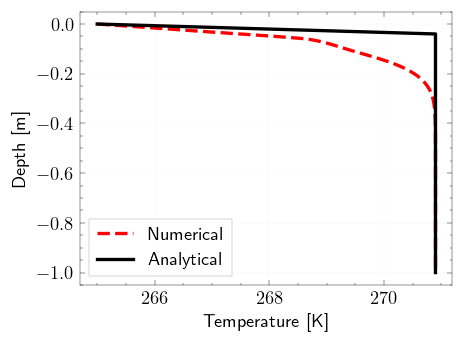

In [6]:
# run the model
results_data = SeaIceModel.get_results(preprocess_data, userinput_data)
analysis_data = Analysis.get_error_results(
            t_k_diff=results_data.t_k_diff,
            t_stefan_diff=results_data.t_stefan_diff,
            residual=results_data.residual_voller_all,
            temperature_mushy=results_data.t_k_iter_all,
            phi_mushy=results_data.all_phi_iter_all,
            salinity_mushy=results_data.s_k_iter_all,
            output_dir=out_dir_final,
        )

#### Visualization of Model:
for more info on other visualization options look at:  [visualize model](https://starry-phoenix.github.io/spyice-thesis/build/html/api/spyice.postprocess.visualise_model.html)

In [7]:
model_visualization_object = VisualiseModel(
    user_input_dataclass=userinput_data,
    results_dataclass=results_data,
    error_analysis_dataclass=analysis_data,
)

Visualisation object created...


Plotting Temperature heatmap...


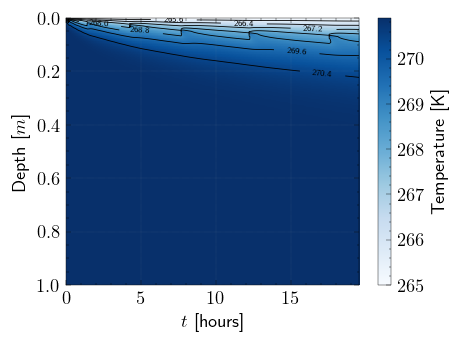

In [8]:
model_visualization_object.plot_temperature_heatmap(savefig=True, export_csv=False, show=True)

Plotting Salinity heatmap...


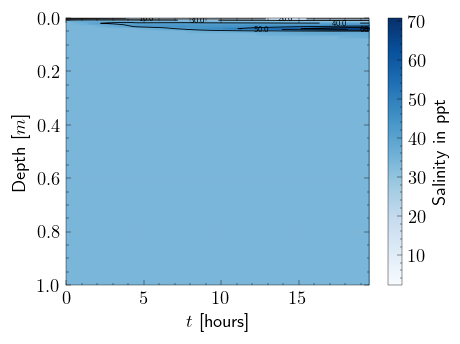

In [9]:
model_visualization_object.plot_salinity_heatmap(savefig=True, show=True)

## Example 2: Demo to change temperature boundary conditions and salt initial conditions in heat-solute transport simulation

Demonstrates a simple example for a freezing sea ice model heat-salt transport setup with different **boundary settings 250K at the top boundary and Salinity of 100ppt** choosing constant fixed Dirichlet boundary conditions. For the one phase distinct interface system where sea water is at melt temperature of 271.25K.


#### Import Packages

In [10]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime

%matplotlib inline
from omegaconf import OmegaConf

from spyice.utils import create_output_directory
from spyice.postprocess import Analysis, VisualiseModel
from spyice.utils import ConfigSort
from spyice.models import SeaIceModel
from spyice.preprocess import PreProcess

#### Define Inputs and Project Output paths

In [11]:
# creates a OmegaConf object from a dictionary for fast testing only for parameters: constants, dt, S_IC, iter_max, dz
# make sure to change userinput_data data class values if any parameters in constants_dict is changed!
constants_dict = {
    "constants": {"constants": "real"},
    "dt": {"dt": 47},
    "S_IC": {"S_IC": "S34"},
    "iter_max": {"iter_max": 1500},
    "dz": {"dz": 0.01},
}
config_raw = OmegaConf.create(constants_dict)
config = ConfigSort.getconfig_dataclass(config_raw, config_type="jupyter")

# choose your output directory
base_dir = Path.cwd()
output_base_dir = Path(base_dir, "output")
# Current date-time string
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_base_dir = Path(output_base_dir, timestamp)
wo_hydra_dir = Path(output_base_dir, "without_hydra")
out_dir_final = create_output_directory(wo_hydra_dir, config.initial_salinity.S_IC, "2", "0.01", "47", "1500","example")

#### Preprocessing

In [12]:
# preprocess the data
preprocess_data, userinput_data = PreProcess.get_variables(config_raw, out_dir_final)

Preprocessing...
User Configuration Data Setup Complete...
Geometry Data Setup Complete...
Results Data Setup Complete...
Time step set to: 47s
Applied Initial & Boundary Conditions...
Preprocessing done.


#### Model settings

for more info on all the model parameters have a look at the documentation: [userinput](
    https://starry-phoenix.github.io/spyice-thesis/build/html/api/spyice.parameters.user_input.html)

In [13]:
# Choose the diffusion only equation for heat diffusion without the influence of salinity and physical properties
userinput_data.is_diffusiononly_equation = False
userinput_data.is_salinity_equation = True

In [14]:
# Top surface boundary temperature of sea ice in K
userinput_data.boundary_top_temperature = 250.0

In [15]:
# Salinity as SX with X being the initial value
# Initial salinity of ocean can be changed as follows:
userinput_data.initial_salinity = "S100"

In [16]:
# Update preprocess data class with new data
preprocess_data = PreProcess.update_preprocess_dataclass(preprocess_data, userinput_data)

Time step set to: 47s
Updated Initial & Boundary Conditions...


#### Run model

Running model...
Model run complete and Ready for Analysis.
Running error analysis...
Calculating errors...
Residuals exported successfully.


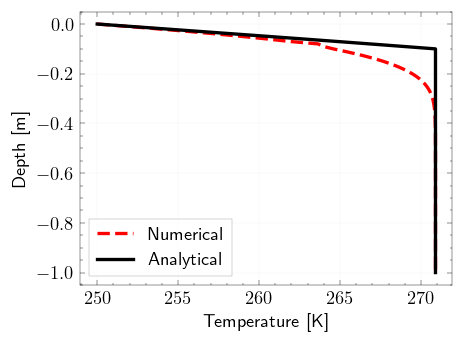

In [17]:
# run the model
results_data = SeaIceModel.get_results(preprocess_data, userinput_data)
analysis_data = Analysis.get_error_results(
    t_k_diff=results_data.t_k_diff,
    t_stefan_diff=results_data.t_stefan_diff,
    residual=results_data.residual_voller_all,
    temperature_mushy=results_data.t_k_iter_all,
    phi_mushy=results_data.all_phi_iter_all,
    salinity_mushy=results_data.s_k_iter_all,
    output_dir=out_dir_final,
)

#### Visualization of Model:
for more info on other visualization options look at:  [visualize model](https://starry-phoenix.github.io/spyice-thesis/build/html/api/spyice.postprocess.visualise_model.html)

In [18]:
model_visualization_object = VisualiseModel(
    user_input_dataclass=userinput_data,
    results_dataclass=results_data,
    error_analysis_dataclass=analysis_data,
)

Visualisation object created...


Plotting Temperature heatmap...


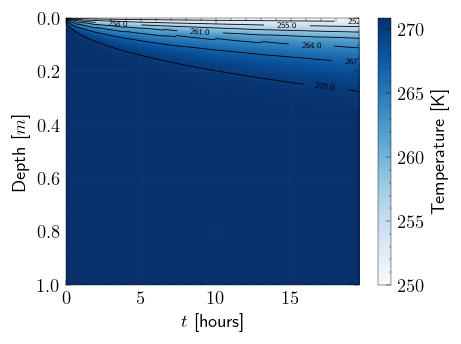

In [19]:
# visualise temperature evolution as heatmap
model_visualization_object.plot_temperature_heatmap(savefig=True, export_csv=False, show=True)

Plotting Salinity heatmap...


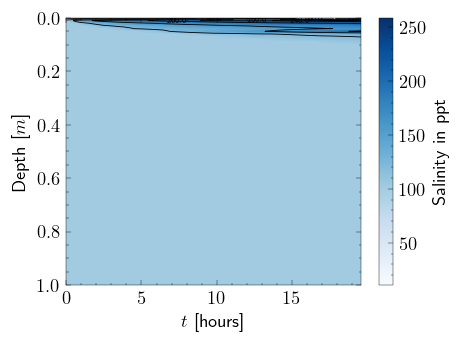

In [20]:
# visualise salinity evolution as heatmap
model_visualization_object.plot_salinity_heatmap(savefig=True, show=True)

Plotting Liquid-Fraction heatmap...


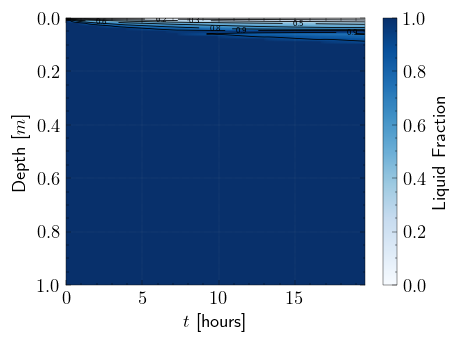

In [21]:
# visualise liquidfraction evolution as heatmap
model_visualization_object.plot_liquidfraction_heatmap(savefig=True, show=True)